# 🌿 Betel Leaf Disease — Feature-Level Fusion Fine-Tuning
**CSE 438 Group-4 | Fine-Tuning: ResNet50 (CNN) + ViT-Small (Transformer) → Feature Concat**

---
## Pipeline Overview
| Step | Description |
|------|-------------|
| Step 1  | Install & Import Libraries |
| Step 2  | Dataset Setup & Config |
| Step 3  | Data Exploration & Class Distribution |
| Step 4  | Augmentation & Transform (with Mixup & CutMix) |
| Step 5  | Dataset & DataLoader Creation |
| Step 6  | Model Definition + Load Pretrained / Resume Checkpoint |
| Step 7  | Fine-Tuning: 3-Phase Strategy with Layer-wise LR Decay |
| Step 8  | Training Curves & LR Schedule Visualization |
| Step 9  | Final Test Evaluation & Metrics |
| Step 10 | Confusion Matrix, Per-Class Report & Feature Analysis |

---
## 🎯 Fine-Tuning Strategy Overview

```
┌─────────────────────────────────────────────────────────────────┐
│               3-PHASE FINE-TUNING PIPELINE                      │
├──────────┬──────────────────────┬──────────────────────────────┤
│ Phase    │ Epochs               │ What trains                  │
├──────────┼──────────────────────┼──────────────────────────────┤
│ Phase 1  │ 1  → WARMUP_EP       │ Fusion Head ONLY             │
│          │ (default: 1-5)       │ Backbones frozen             │
│          │                      │ Head LR = 1e-3 (warm-up)     │
├──────────┼──────────────────────┼──────────────────────────────┤
│ Phase 2  │ WARMUP+1 → MID_EP    │ Unfreeze last N CNN layers   │
│          │ (default: 6-12)      │ Unfreeze last N ViT blocks   │
│          │                      │ Layer-wise LR decay applied  │
├──────────┼──────────────────────┼──────────────────────────────┤
│ Phase 3  │ MID_EP+1 → NUM_EP    │ ALL layers unfrozen          │
│          │ (default: 13-25)     │ Very low LR for backbones    │
│          │                      │ Cosine annealing decay       │
└──────────┴──────────────────────┴──────────────────────────────┘
```

> **Layer-wise LR Decay:** Each deeper backbone layer gets a lower LR  
> `LR_layer = base_lr × decay_rate^(depth_from_head)`  
> CNN decay = 0.85 per layer group | ViT decay = 0.75 per transformer block


---
## ✅ Step 1 — Install & Import Libraries

In [1]:
import subprocess, sys
packages = ["timm", "scikit-learn", "matplotlib", "seaborn", "Pillow", "torchvision"]
for pkg in packages:
    result = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                            capture_output=True, text=True)
    print(f"[OK] {pkg}" if result.returncode == 0 else f"[FAIL] {pkg}: {result.stderr[:80]}")
print("\n✅ All packages ready!")

import os, random, time, math, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as tv_models
import timm

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   PyTorch : {torch.__version__}")
print(f"   timm    : {timm.__version__}")

[OK] timm
[OK] scikit-learn
[OK] matplotlib
[OK] seaborn
[OK] Pillow
[OK] torchvision

✅ All packages ready!

🖥️  Device  : cuda
   GPU     : Tesla T4
   VRAM    : 15.6 GB
   PyTorch : 2.10.0+cu128
   timm    : 1.0.25


---
## ✅ Step 2 — Dataset Setup & Config

> On Kaggle: **Add Data → Datasets** → search `"Comprehensive Betel Leaf Disease"` → add.  
> If you have a **pretrained checkpoint** from the base training notebook, put the path in `PRETRAIN_CKPT`.

In [2]:
CLASS_NAMES  = ["Healthy_Leaf", "Leaf_Rot", "Leaf_Spot"]
DATASET_ROOT = None

for root in ["/kaggle/input", "./data", "."]:
    for dirpath, dirnames, _ in os.walk(root):
        if "Original_Dataset" in dirnames:
            DATASET_ROOT = Path(dirpath) / "Original_Dataset"
            print(f"✅ Found Original_Dataset at: {DATASET_ROOT}")
            break
    if DATASET_ROOT: break

if DATASET_ROOT is None:
    print("⚠️  Original_Dataset not found — creating synthetic demo data...")
    DATASET_ROOT = Path("/kaggle/working/demo_dataset")
    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            (DATASET_ROOT / split / cls).mkdir(parents=True, exist_ok=True)
            for i in range(40 if split == "train" else 12):
                img = Image.fromarray(np.random.randint(50, 200, (224, 224, 3), dtype=np.uint8))
                img.save(DATASET_ROOT / split / cls / f"img_{i:04d}.jpg")
    DEMO_MODE = True
    print(f"✅ Demo dataset created at: {DATASET_ROOT}")
else:
    DEMO_MODE = False

if not DEMO_MODE:
    from sklearn.model_selection import train_test_split
    import shutil
    SPLIT_ROOT = Path("/kaggle/working/split_dataset")
    if not SPLIT_ROOT.exists():
        print("\n📁 Creating train/val/test splits (70 / 15 / 15)...")
        for cls in CLASS_NAMES:
            all_imgs = (sorted((DATASET_ROOT / cls).glob("*.jpg")) +
                        sorted((DATASET_ROOT / cls).glob("*.png")) +
                        sorted((DATASET_ROOT / cls).glob("*.jpeg")))
            tr, temp = train_test_split(all_imgs, test_size=0.30, random_state=SEED)
            vl, te   = train_test_split(temp,     test_size=0.50, random_state=SEED)
            for sname, imgs in [("train", tr), ("val", vl), ("test", te)]:
                dest = SPLIT_ROOT / sname / cls
                dest.mkdir(parents=True, exist_ok=True)
                for src in imgs: shutil.copy(src, dest / src.name)
            print(f"   {cls:<15} → train:{len(tr):4d}  val:{len(vl):4d}  test:{len(te):4d}")
        print("✅ Splits ready!")
    DATASET_ROOT = SPLIT_ROOT

print("\n📊 Dataset Summary:")
for split in ["train", "val", "test"]:
    total = sum(len(list((DATASET_ROOT / split / c).glob("*.*")))
                for c in CLASS_NAMES if (DATASET_ROOT / split / c).exists())
    print(f"   {split:>5}: {total:5d} images")

# ── Fine-Tuning Config ────────────────────────────────────────────────────
IMG_SIZE     = 224
NUM_CLASSES  = len(CLASS_NAMES)
BATCH_SIZE   = 16      # smaller batch → more gradient updates, better for fine-tuning
NUM_EPOCHS   = 25      # more epochs for fine-tuning
NUM_WORKERS  = 2

# Phase boundaries
WARMUP_EP    = 5       # Phase 1: head-only warmup epochs
MID_EP       = 12      # Phase 2: partial unfreeze ends at this epoch
                       # Phase 3: full unfreeze from epoch MID_EP+1

# Learning rates
HEAD_LR_WARM = 1e-3   # Phase 1: head warmup LR
HEAD_LR_FINE = 3e-4   # Phase 2/3: head fine-tune LR
CNN_BASE_LR  = 5e-5   # Phase 2/3: CNN last layer LR (decays for deeper layers)
VIT_BASE_LR  = 2e-5   # Phase 2/3: ViT last block LR (decays for earlier blocks)

# Layer-wise LR decay
CNN_LR_DECAY = 0.85    # each CNN layer group: LR × 0.85
VIT_LR_DECAY = 0.75    # each ViT block deeper: LR × 0.75

# Regularization
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
MIXUP_ALPHA  = 0.2     # Mixup augmentation alpha (0 = disabled)

# Dimensions
CNN_FEAT_DIM  = 2048
VIT_FEAT_DIM  = 384
FUSED_DIM     = CNN_FEAT_DIM + VIT_FEAT_DIM
FUSION_HIDDEN = 512

# Checkpoint paths
PRETRAIN_CKPT = "/kaggle/working/best_feat_fusion_model.pth"  # from base training notebook
FINETUNE_CKPT = "/kaggle/working/best_feat_fusion_finetuned.pth"

PREFIX     = "feat_ft"
MODEL_NAME = "Feature-Fusion Fine-Tuned (ResNet50+ViT-Small)"

print(f"\n⚙️  Fine-Tuning Config:")
print(f"   Batch={BATCH_SIZE}  Epochs={NUM_EPOCHS}  IMG={IMG_SIZE}")
print(f"   Phase 1 (ep 1-{WARMUP_EP})   : head warmup  LR={HEAD_LR_WARM}")
print(f"   Phase 2 (ep {WARMUP_EP+1}-{MID_EP}) : partial unfreeze LR decay")
print(f"   Phase 3 (ep {MID_EP+1}-{NUM_EPOCHS}) : full finetune LR decay")
print(f"   CNN LR decay: {CNN_LR_DECAY} per layer group")
print(f"   ViT LR decay: {VIT_LR_DECAY} per block")
print(f"   Pretrained ckpt: {PRETRAIN_CKPT}")

✅ Found Original_Dataset at: /kaggle/input/datasets/mikeafridi/cse-438-group-4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset

📁 Creating train/val/test splits (70 / 15 / 15)...
   Healthy_Leaf    → train: 756  val: 162  test: 162
   Leaf_Rot        → train: 188  val:  40  test:  41
   Leaf_Spot       → train: 481  val: 103  test: 104
✅ Splits ready!

📊 Dataset Summary:
   train:  1425 images
     val:   305 images
    test:   307 images

⚙️  Fine-Tuning Config:
   Batch=16  Epochs=25  IMG=224
   Phase 1 (ep 1-5)   : head warmup  LR=0.001
   Phase 2 (ep 6-12) : partial unfreeze LR decay
   Phase 3 (ep 13-25) : full finetune LR decay
   CNN LR decay: 0.85 per layer group
   ViT LR decay: 0.75 per block
   Pretrained ckpt: /kaggle/working/best_feat_fusion_model.pth


---
## ✅ Step 3 — Data Exploration & Class Distribution

📊 Class Distribution Table
Split         test  train  val
Class                         
Healthy_Leaf   162    756  162
Leaf_Rot        41    188   40
Leaf_Spot      104    481  103


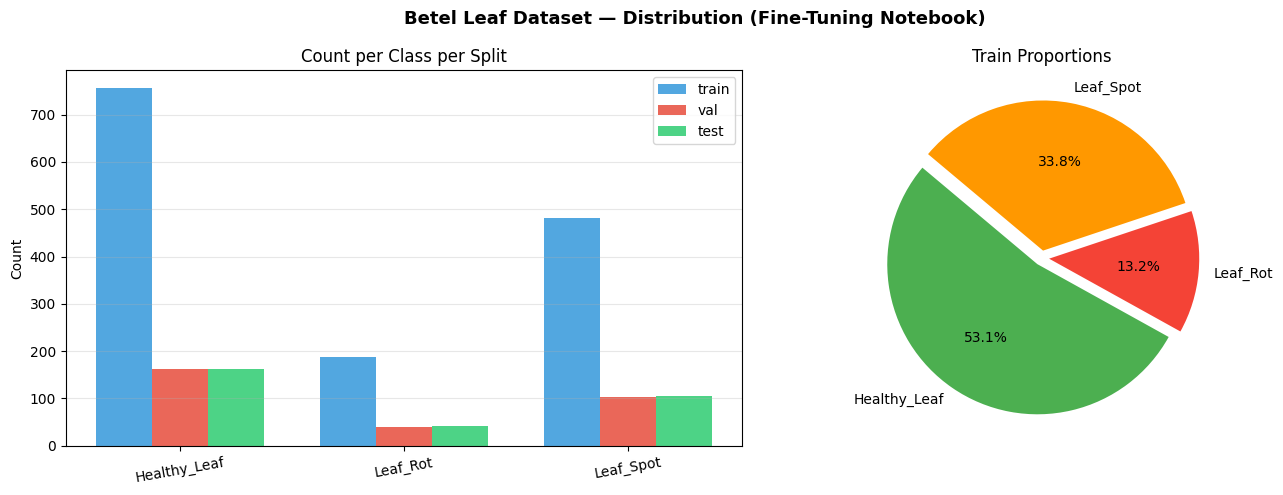

✅ Step 3 complete.


In [3]:
records = []
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        folder = DATASET_ROOT / split / cls
        if folder.exists():
            imgs = (list(folder.glob("*.jpg")) + list(folder.glob("*.png")) +
                    list(folder.glob("*.jpeg")))
            records.append({"Split": split, "Class": cls, "Count": len(imgs)})

df_dist = pd.DataFrame(records)
print("📊 Class Distribution Table")
print(df_dist.pivot(index="Class", columns="Split", values="Count").fillna(0).astype(int))

colors = ["#4CAF50", "#F44336", "#FF9800"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Betel Leaf Dataset — Distribution (Fine-Tuning Notebook)",
             fontsize=13, fontweight="bold")
ax = axes[0]
x = np.arange(len(CLASS_NAMES)); w = 0.25
for i, (split, col) in enumerate(zip(["train","val","test"],
                                      ["#3498db","#e74c3c","#2ecc71"])):
    vals = [df_dist[(df_dist.Split==split) & (df_dist.Class==c)]["Count"].sum()
            for c in CLASS_NAMES]
    ax.bar(x + i*w, vals, w, label=split, color=col, alpha=0.85)
ax.set_xticks(x+w); ax.set_xticklabels(CLASS_NAMES, rotation=10)
ax.set_title("Count per Class per Split"); ax.set_ylabel("Count")
ax.legend(); ax.grid(axis="y", alpha=0.3)
ax2 = axes[1]
train_cnts = [df_dist[(df_dist.Split=="train")&(df_dist.Class==c)]["Count"].sum()
              for c in CLASS_NAMES]
ax2.pie(train_cnts, labels=CLASS_NAMES, colors=colors, autopct="%1.1f%%",
        startangle=140, explode=[0.05]*3)
ax2.set_title("Train Proportions")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step3_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Step 3 complete.")

---
## ✅ Step 4 — Augmentation & Transform (with Mixup)

Fine-tuning uses **stronger augmentation** than base training to improve generalization:
- **RandAugment** — automated augmentation policy
- **RandomErasing** — occlusion robustness
- **Mixup** — interpolates two images + labels during training

```
Mixup: x̃ = λ·xᵢ + (1−λ)·xⱼ
        ỹ = λ·yᵢ + (1−λ)·yⱼ
        λ ~ Beta(α, α),  α = 0.2
```

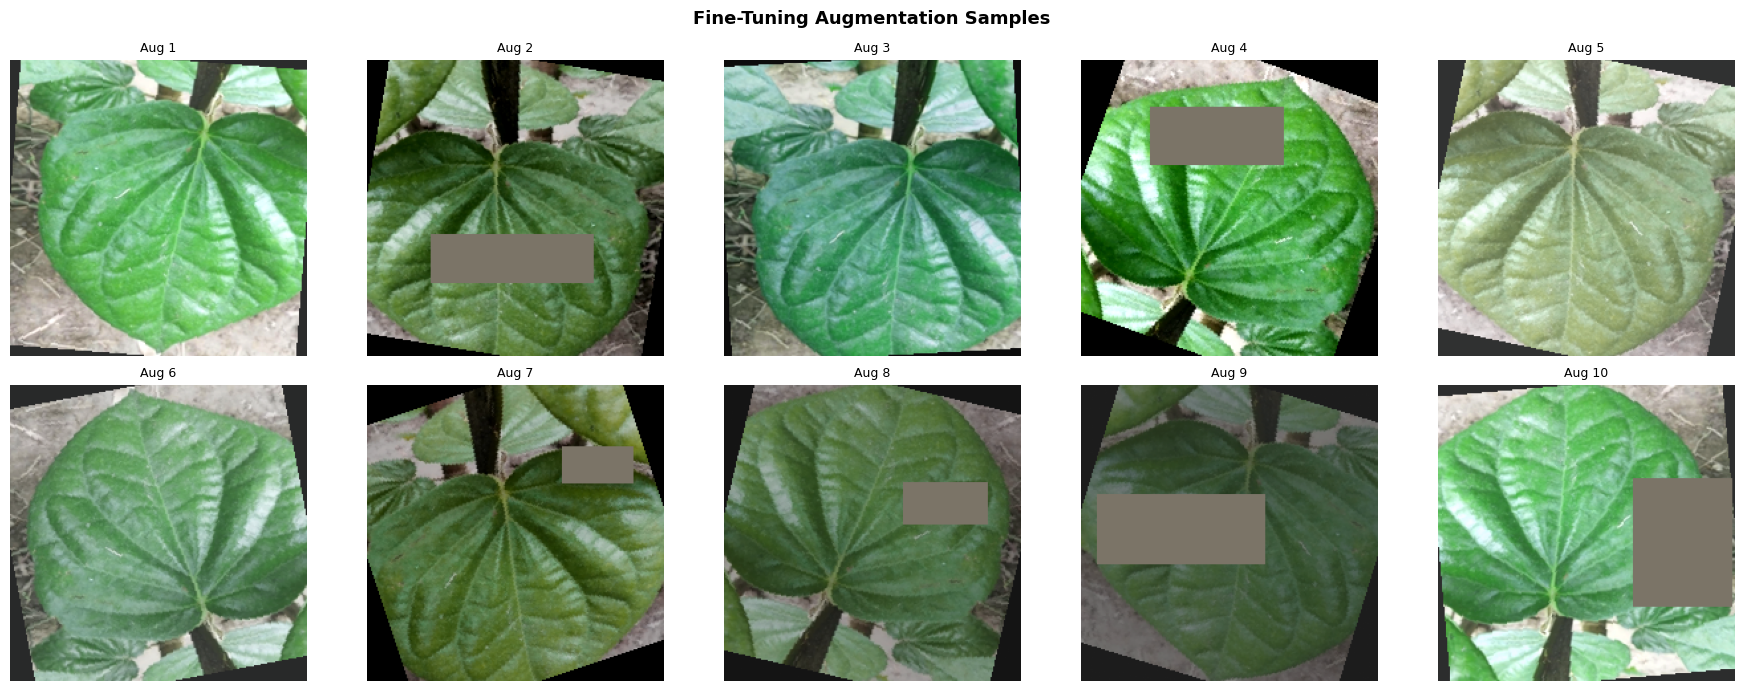

✅ Step 4 complete — Fine-tuning transforms ready
   Mixup alpha : 0.2 (enabled)


In [4]:
MEAN_RGB = [0.485, 0.456, 0.406]
STD_RGB  = [0.229, 0.224, 0.225]

# Fine-tuning train transform — stronger than base training
train_transform = transforms.Compose([
    transforms.Resize((int(IMG_SIZE * 1.15), int(IMG_SIZE * 1.15))),
    transforms.RandomCrop(IMG_SIZE),               # random crop instead of direct resize
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),         # wider rotation than base
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_RGB, STD_RGB),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),  # random patch erasing
])

# Val / Test transform — clean, no augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_RGB, STD_RGB),
])


# ── Mixup Augmentation ────────────────────────────────────────────────────
def mixup_batch(images, labels, num_classes, alpha=0.2):
    """
    Apply Mixup to a batch of images and one-hot labels.
    Returns mixed images and soft labels.
    λ ~ Beta(alpha, alpha)
    """
    if alpha <= 0:
        # Mixup disabled — return one-hot labels
        return images, F.one_hot(labels, num_classes).float()

    lam   = np.random.beta(alpha, alpha)
    B     = images.size(0)
    idx   = torch.randperm(B, device=images.device)

    mixed_imgs   = lam * images + (1 - lam) * images[idx]
    labels_onehot = F.one_hot(labels, num_classes).float()
    mixed_labels = lam * labels_onehot + (1 - lam) * labels_onehot[idx]
    return mixed_imgs, mixed_labels


def mixup_criterion(criterion_fn, logits, soft_labels):
    """Cross-entropy loss for soft (mixup) labels."""
    log_probs = F.log_softmax(logits, dim=1)
    return -(soft_labels * log_probs).sum(dim=1).mean()


# Visualize augmented samples
sample_path = list((DATASET_ROOT / "train" / CLASS_NAMES[0]).glob("*.*"))[0]
sample_pil  = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Fine-Tuning Augmentation Samples", fontsize=13, fontweight="bold")
mean_t = torch.tensor(MEAN_RGB).view(3,1,1)
std_t  = torch.tensor(STD_RGB).view(3,1,1)

for i in range(10):
    aug_t = train_transform(sample_pil)
    disp  = (aug_t * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
    r, c  = i // 5, i % 5
    axes[r][c].imshow(disp)
    axes[r][c].set_title(f"Aug {i+1}", fontsize=9)
    axes[r][c].axis("off")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step4_augmentation.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✅ Step 4 complete — Fine-tuning transforms ready")
print(f"   Mixup alpha : {MIXUP_ALPHA} ({'enabled' if MIXUP_ALPHA > 0 else 'disabled'})")

---
## ✅ Step 5 — Dataset & DataLoader Creation

In [5]:
class BetelLeafDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.class_names  = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.transform    = transform
        self.samples      = []
        for cls in class_names:
            folder = Path(root_dir) / cls
            if not folder.exists(): continue
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
                for p in sorted(folder.glob(ext)):
                    self.samples.append((str(p), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:    img = Image.open(path).convert("RGB")
        except: img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        if self.transform: img = self.transform(img)
        return img, label


train_ds = BetelLeafDataset(DATASET_ROOT/"train", CLASS_NAMES, train_transform)
val_ds   = BetelLeafDataset(DATASET_ROOT/"val",   CLASS_NAMES, val_transform)
test_ds  = BetelLeafDataset(DATASET_ROOT/"test",  CLASS_NAMES, val_transform)
print(f"📦 Sizes → Train:{len(train_ds)}  Val:{len(val_ds)}  Test:{len(test_ds)}")

# WeightedRandomSampler for class imbalance
labels_train = [s[1] for s in train_ds.samples]
class_counts = Counter(labels_train)
weights      = [1.0 / class_counts[l] for l in labels_train]
sampler      = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n🔍 Batch check:")
print(f"   Image tensor : {batch_imgs.shape}")
print(f"   Labels       : {batch_labels[:8].tolist()}")
print(f"   Value range  : [{batch_imgs.min():.3f}, {batch_imgs.max():.3f}]")
print("\n✅ Step 5 complete — DataLoaders ready!")

📦 Sizes → Train:1425  Val:305  Test:307

🔍 Batch check:
   Image tensor : torch.Size([16, 3, 224, 224])
   Labels       : [0, 2, 2, 0, 2, 0, 0, 2]
   Value range  : [-2.118, 2.640]

✅ Step 5 complete — DataLoaders ready!


---
## ✅ Step 6 — Model Definition + Load Pretrained / Resume Checkpoint

**Model architecture is identical to the base training notebook.**  
This step:
1. Re-defines the same `FeatureLevelFusionModel`
2. Loads weights from the base training checkpoint (`best_feat_fusion_model.pth`)
3. If no checkpoint found → trains from ImageNet pretrained weights

### Layer-wise LR Decay Logic
```
CNN layers (ResNet50):    layer4 > layer3 > layer2 > layer1
  LR:                     5e-5  > 4.3e-5 > 3.6e-5 > 3.1e-5  (× 0.85 each)

ViT blocks (ViT-Small):   block11 > block10 > ... > block0
  LR:                     2e-5   > 1.5e-5  > ...  > tiny    (× 0.75 each)
```

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Model Definition (same architecture as base notebook)
# ═══════════════════════════════════════════════════════════════════════════

class CNNBranch(nn.Module):
    """ResNet50 backbone — outputs global avg pooled features [B, 2048]."""
    def __init__(self):
        super().__init__()
        backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])

    def forward(self, x):
        return self.features(x).flatten(1)   # [B, 2048]


class ViTBranch(nn.Module):
    """ViT-Small/16 backbone — outputs CLS token features [B, 384]."""
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "vit_small_patch16_224", pretrained=True, num_classes=0
        )

    def forward(self, x):
        return self.backbone(x)              # [B, 384]


class FusionHead(nn.Module):
    """2-layer MLP fusion head: [B, 2432] → [B, num_classes]."""
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x): return self.net(x)


class FeatureLevelFusionModel(nn.Module):
    """ResNet50 (CNN) + ViT-Small (Transformer) → concat → MLP head."""
    def __init__(self, num_classes=3, fusion_hidden=512, dropout=0.4):
        super().__init__()
        self.cnn_branch  = CNNBranch()
        self.vit_branch  = ViTBranch()
        self.fusion_head = FusionHead(CNN_FEAT_DIM + VIT_FEAT_DIM,
                                      fusion_hidden, num_classes, dropout)

    def freeze_backbones(self):
        for p in self.cnn_branch.parameters():  p.requires_grad = False
        for p in self.vit_branch.parameters():  p.requires_grad = False
        for p in self.fusion_head.parameters(): p.requires_grad = True

    def unfreeze_cnn_last_n(self, n=2):
        """Unfreeze the last n layer-groups of ResNet50."""
        # ResNet50 layer groups: layer1, layer2, layer3, layer4
        cnn_children = list(self.cnn_branch.features.children())
        # last n groups (layer4 = index -1, layer3 = -2, etc.)
        for child in cnn_children[-n:]:
            for p in child.parameters(): p.requires_grad = True

    def unfreeze_vit_last_n(self, n=4):
        """Unfreeze the last n transformer blocks of ViT-Small."""
        blocks = list(self.vit_branch.backbone.blocks)
        for block in blocks[-n:]:
            for p in block.parameters(): p.requires_grad = True
        # Always unfreeze norm and head
        for p in self.vit_branch.backbone.norm.parameters(): p.requires_grad = True

    def unfreeze_all(self):
        for p in self.parameters(): p.requires_grad = True

    def forward(self, x):
        cnn_feat = self.cnn_branch(x)                      # [B, 2048]
        vit_feat = self.vit_branch(x)                      # [B, 384]
        fused    = torch.cat([cnn_feat, vit_feat], dim=1)  # [B, 2432]
        return self.fusion_head(fused)                     # [B, num_classes]


# ── Instantiate model ─────────────────────────────────────────────────────
model = FeatureLevelFusionModel(
    num_classes=NUM_CLASSES, fusion_hidden=FUSION_HIDDEN, dropout=0.4
).to(DEVICE)

# ── Load pretrained checkpoint (from base training notebook) ──────────────
START_EPOCH = 1
if Path(PRETRAIN_CKPT).exists():
    ckpt = torch.load(PRETRAIN_CKPT, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"✅ Loaded pretrained checkpoint: {PRETRAIN_CKPT}")
    print(f"   Pretrained val loss : {ckpt.get('val_loss', 'N/A')}")
    print(f"   Pretrained val acc  : {ckpt.get('val_acc', 0)*100:.2f}%")
    print(f"   Pretrained val F1   : {ckpt.get('val_f1', 'N/A')}")
else:
    print(f"⚠️  No pretrained checkpoint found at: {PRETRAIN_CKPT}")
    print(f"   Starting fine-tuning from ImageNet pretrained weights.")

# ── Parameter count ───────────────────────────────────────────────────────
total_p = sum(p.numel() for p in model.parameters())
cnn_p   = sum(p.numel() for p in model.cnn_branch.parameters())
vit_p   = sum(p.numel() for p in model.vit_branch.parameters())
head_p  = sum(p.numel() for p in model.fusion_head.parameters())
print(f"\n🏗️  Model: Feature-Level Fusion (Fine-Tuning)")
print(f"   CNN Branch  (ResNet50)     : {cnn_p:>12,} params")
print(f"   ViT Branch  (ViT-Small/16) : {vit_p:>12,} params")
print(f"   Fusion Head (MLP)          : {head_p:>12,} params")
print(f"   Total                      : {total_p:>12,} params")

# ── Forward pass check ────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
print(f"\n✅ Forward pass OK — output shape: {out.shape}")
print("\n✅ Step 6 complete — Model loaded and ready for fine-tuning!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

⚠️  No pretrained checkpoint found at: /kaggle/working/best_feat_fusion_model.pth
   Starting fine-tuning from ImageNet pretrained weights.

🏗️  Model: Feature-Level Fusion (Fine-Tuning)
   CNN Branch  (ResNet50)     :   23,508,032 params
   ViT Branch  (ViT-Small/16) :   21,665,664 params
   Fusion Head (MLP)          :    1,248,259 params
   Total                      :   46,421,955 params

✅ Forward pass OK — output shape: torch.Size([2, 3])

✅ Step 6 complete — Model loaded and ready for fine-tuning!


---
## ✅ Step 7 — Fine-Tuning: 3-Phase Strategy with Layer-wise LR Decay

### 3-Phase Fine-Tuning Strategy

```
Phase 1 — Warmup (ep 1–5)
  ├── Backbone:    FROZEN
  ├── Head:        TRAINABLE  (LR = 1e-3)
  └── Goal:        Stabilize fusion head before touching backbone weights

Phase 2 — Partial Unfreeze (ep 6–12)
  ├── CNN:         Unfreeze last 2 layer groups (layer3, layer4)
  ├── ViT:         Unfreeze last 4 transformer blocks
  ├── LR:          Layer-wise decay applied
  └── Goal:        Adapt task-specific features while keeping early layers stable

Phase 3 — Full Fine-tune (ep 13–25)
  ├── All layers:  TRAINABLE
  ├── LR:          Very low for early layers, higher for later layers
  └── Goal:        End-to-end optimization
```

### Layer-wise LR Decay Formula
```
CNN:  LR_layerᵢ = CNN_BASE_LR × CNN_LR_DECAY^(depth_from_output)
ViT:  LR_blockᵢ = VIT_BASE_LR × VIT_LR_DECAY^(depth_from_last_block)
```

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Layer-wise LR parameter groups builder
# ═══════════════════════════════════════════════════════════════════════════

def build_layerwise_param_groups(model, head_lr, cnn_base_lr, vit_base_lr,
                                  cnn_decay, vit_decay, weight_decay):
    """
    Build parameter groups with layer-wise LR decay.

    CNN (ResNet50) groups (shallow → deep):
        conv1+bn1 | layer1 | layer2 | layer3 | layer4
        LR:  base×decay⁴  base×decay³  base×decay²  base×decay¹  base×decay⁰

    ViT groups: each block gets LR = vit_base_lr × vit_decay^(num_blocks-1-i)
        block0 (deepest decay) ... block11 (closest to output, highest LR)

    Fusion Head: head_lr (no decay)
    """
    param_groups = []

    # ── 1. CNN Branch: ResNet50 layer-wise LR ─────────────────────────────
    # ResNet50 structure inside CNNBranch.features:
    # [0]=conv1, [1]=bn1, [2]=relu, [3]=maxpool,
    # [4]=layer1, [5]=layer2, [6]=layer3, [7]=layer4, [8]=avgpool
    cnn_layer_groups = [
        ("cnn_stem",   list(model.cnn_branch.features.children())[:4]),   # conv1,bn1,relu,pool
        ("cnn_layer1", list(model.cnn_branch.features.children())[4:5]),
        ("cnn_layer2", list(model.cnn_branch.features.children())[5:6]),
        ("cnn_layer3", list(model.cnn_branch.features.children())[6:7]),
        ("cnn_layer4", list(model.cnn_branch.features.children())[7:8]),
    ]
    num_cnn_groups = len(cnn_layer_groups)  # 5
    for depth_from_output, (name, layers) in enumerate(
            reversed(cnn_layer_groups)):  # layer4=depth0, stem=depth4
        lr = cnn_base_lr * (cnn_decay ** depth_from_output)
        params = [p for layer in layers
                    for p in layer.parameters() if p.requires_grad]
        if params:
            param_groups.append({"params": params, "lr": lr,
                                  "weight_decay": weight_decay,
                                  "name": name})

    # ── 2. ViT Branch: block-wise LR ─────────────────────────────────────
    # ViT-Small: patch_embed | pos_drop | blocks[0..11] | norm
    vit_backbone = model.vit_branch.backbone

    # Patch embedding + positional embedding (deepest, lowest LR)
    embed_params = [p for p in vit_backbone.patch_embed.parameters() if p.requires_grad]
    if hasattr(vit_backbone, 'pos_embed'):
        if vit_backbone.pos_embed.requires_grad:
            embed_params.append(vit_backbone.pos_embed)
    if embed_params:
        embed_lr = vit_base_lr * (vit_decay ** 12)  # deepest
        param_groups.append({"params": embed_params, "lr": embed_lr,
                              "weight_decay": weight_decay, "name": "vit_embed"})

    # Transformer blocks: block 0 (lowest LR) → block 11 (highest LR)
    num_vit_blocks = len(vit_backbone.blocks)
    for i, block in enumerate(vit_backbone.blocks):
        depth_from_output = num_vit_blocks - 1 - i   # block11=0, block0=11
        lr = vit_base_lr * (vit_decay ** depth_from_output)
        params = [p for p in block.parameters() if p.requires_grad]
        if params:
            param_groups.append({"params": params, "lr": lr,
                                  "weight_decay": weight_decay,
                                  "name": f"vit_block{i}"})

    # Norm layer
    norm_params = [p for p in vit_backbone.norm.parameters() if p.requires_grad]
    if norm_params:
        param_groups.append({"params": norm_params, "lr": vit_base_lr,
                              "weight_decay": weight_decay, "name": "vit_norm"})

    # ── 3. Fusion Head: highest LR ────────────────────────────────────────
    head_params = [p for p in model.fusion_head.parameters() if p.requires_grad]
    if head_params:
        param_groups.append({"params": head_params, "lr": head_lr,
                              "weight_decay": weight_decay, "name": "fusion_head"})

    return param_groups


# ── Training helper functions ─────────────────────────────────────────────

def train_one_epoch_mixup(model, loader, optimizer, device, num_classes, alpha):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        # Apply Mixup
        mixed_imgs, soft_labels = mixup_batch(imgs, labels, num_classes, alpha)

        optimizer.zero_grad()
        logits = model(mixed_imgs)
        loss   = mixup_criterion(None, logits, soft_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        # Accuracy: use original (non-mixed) labels
        with torch.no_grad():
            correct += (model(imgs).argmax(1) == labels).sum().item()
        total  += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ce_loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs     = model(imgs)
        total_loss += ce_loss_fn(outputs, labels).item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss/total, correct/total,
            np.array(all_preds), np.array(all_labels))


def log_lr_groups(optimizer, epoch):
    """Print current LR for key param groups."""
    groups = optimizer.param_groups
    key_names = ["cnn_layer4", "vit_block11", "vit_norm", "fusion_head"]
    for g in groups:
        if g.get("name") in key_names:
            print(f"     {g['name']:<15} LR = {g['lr']:.2e}")


# ── Phase 1: Head-only Warmup ─────────────────────────────────────────────
print("=" * 65)
print("  PHASE 1 — Warmup: Backbone FROZEN, Head trains only")
print("=" * 65)
model.freeze_backbones()

# Simple optimizer for warmup — only head params
optimizer_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LR_WARM, weight_decay=WEIGHT_DECAY
)
scheduler_p1 = optim.lr_scheduler.OneCycleLR(
    optimizer_p1, max_lr=HEAD_LR_WARM,
    steps_per_epoch=len(train_loader), epochs=WARMUP_EP,
    pct_start=0.3, anneal_strategy="cos"
)

history = {
    "train_loss": [], "val_loss":  [], "train_acc": [],
    "val_acc":    [], "val_f1":    [], "phase":     []
}
best_val_loss = float("inf")
best_val_acc  = 0.0
no_improve    = 0
patience      = 8
start_total   = time.time()

print(f"{'Ep':>4} {'Ph':>3} {'TrLoss':>8} {'TrAcc':>8} "
      f"{'VaLoss':>8} {'VaAcc':>8} {'VaF1':>7}")
print("-" * 60)

for epoch in range(1, WARMUP_EP + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch_mixup(
        model, train_loader, optimizer_p1, DEVICE, NUM_CLASSES, MIXUP_ALPHA)
    val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, DEVICE)
    val_f1 = f1_score(val_true, val_preds, average="weighted", zero_division=0)
    scheduler_p1.step()

    for k, v in zip(["train_loss","val_loss","train_acc","val_acc","val_f1","phase"],
                    [train_loss,   val_loss,   train_acc,  val_acc,  val_f1,  1]):
        history[k].append(v)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss; best_val_acc = val_acc
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1,
                    "phase": 1}, FINETUNE_CKPT)
        no_improve = 0; marker = " ✓"
    else:
        no_improve += 1

    print(f"{epoch:>4}  🔒  {train_loss:>8.4f} {train_acc*100:>7.2f}% "
          f"{val_loss:>8.4f} {val_acc*100:>7.2f}% {val_f1:>7.4f}  "
          f"({time.time()-t0:.1f}s){marker}")

print(f"\n✅ Phase 1 done — Best val acc: {best_val_acc*100:.2f}%")


# ── Phase 2: Partial Unfreeze with Layer-wise LR ─────────────────────────
print()
print("=" * 65)
print("  PHASE 2 — Partial Unfreeze: last CNN layers + last ViT blocks")
print("=" * 65)

# Unfreeze last 2 CNN groups and last 4 ViT blocks
model.unfreeze_cnn_last_n(n=2)   # layer3, layer4
model.unfreeze_vit_last_n(n=4)   # blocks 8-11 + norm
for p in model.fusion_head.parameters(): p.requires_grad = True

p2_groups = build_layerwise_param_groups(
    model,
    head_lr=HEAD_LR_FINE,
    cnn_base_lr=CNN_BASE_LR,
    vit_base_lr=VIT_BASE_LR,
    cnn_decay=CNN_LR_DECAY,
    vit_decay=VIT_LR_DECAY,
    weight_decay=WEIGHT_DECAY
)
optimizer_p2 = optim.AdamW(p2_groups)
scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=(MID_EP - WARMUP_EP), eta_min=1e-7
)

print("  LR per group (Phase 2):")
log_lr_groups(optimizer_p2, WARMUP_EP + 1)
print()

no_improve_p2 = 0
for epoch in range(WARMUP_EP + 1, MID_EP + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch_mixup(
        model, train_loader, optimizer_p2, DEVICE, NUM_CLASSES, MIXUP_ALPHA)
    val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, DEVICE)
    val_f1 = f1_score(val_true, val_preds, average="weighted", zero_division=0)
    scheduler_p2.step()

    for k, v in zip(["train_loss","val_loss","train_acc","val_acc","val_f1","phase"],
                    [train_loss,   val_loss,   train_acc,  val_acc,  val_f1,  2]):
        history[k].append(v)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss; best_val_acc = val_acc
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer_p2.state_dict(),
                    "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1,
                    "phase": 2}, FINETUNE_CKPT)
        no_improve_p2 = 0; marker = " ✓"
    else:
        no_improve_p2 += 1

    print(f"{epoch:>4}  🔓  {train_loss:>8.4f} {train_acc*100:>7.2f}% "
          f"{val_loss:>8.4f} {val_acc*100:>7.2f}% {val_f1:>7.4f}  "
          f"({time.time()-t0:.1f}s){marker}")
    if no_improve_p2 >= patience:
        print(f"  ⏹️  Early stop (Phase 2) at epoch {epoch}"); break

print(f"\n✅ Phase 2 done — Best val acc: {best_val_acc*100:.2f}%")


# ── Phase 3: Full Fine-tune ───────────────────────────────────────────────
print()
print("=" * 65)
print("  PHASE 3 — Full Fine-tune: ALL layers, layer-wise LR decay")
print("=" * 65)

model.unfreeze_all()

# Rebuild param groups with all layers trainable
p3_groups = build_layerwise_param_groups(
    model,
    head_lr=HEAD_LR_FINE,
    cnn_base_lr=CNN_BASE_LR * 0.5,   # halve CNN base LR for phase 3
    vit_base_lr=VIT_BASE_LR * 0.5,   # halve ViT base LR for phase 3
    cnn_decay=CNN_LR_DECAY,
    vit_decay=VIT_LR_DECAY,
    weight_decay=WEIGHT_DECAY
)
optimizer_p3 = optim.AdamW(p3_groups)
scheduler_p3 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p3, T_max=(NUM_EPOCHS - MID_EP), eta_min=1e-8
)

print("  LR per group (Phase 3):")
log_lr_groups(optimizer_p3, MID_EP + 1)
print()

no_improve_p3 = 0
for epoch in range(MID_EP + 1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch_mixup(
        model, train_loader, optimizer_p3, DEVICE, NUM_CLASSES, MIXUP_ALPHA)
    val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, DEVICE)
    val_f1 = f1_score(val_true, val_preds, average="weighted", zero_division=0)
    scheduler_p3.step()

    for k, v in zip(["train_loss","val_loss","train_acc","val_acc","val_f1","phase"],
                    [train_loss,   val_loss,   train_acc,  val_acc,  val_f1,  3]):
        history[k].append(v)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss; best_val_acc = val_acc
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer_p3.state_dict(),
                    "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1,
                    "phase": 3}, FINETUNE_CKPT)
        no_improve_p3 = 0; marker = " ✓"
    else:
        no_improve_p3 += 1

    print(f"{epoch:>4}  🔥  {train_loss:>8.4f} {train_acc*100:>7.2f}% "
          f"{val_loss:>8.4f} {val_acc*100:>7.2f}% {val_f1:>7.4f}  "
          f"({time.time()-t0:.1f}s){marker}")
    if no_improve_p3 >= patience:
        print(f"  ⏹️  Early stop (Phase 3) at epoch {epoch}"); break

print(f"\n✅ All phases done in {(time.time()-start_total)/60:.1f} min")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Best val acc  : {best_val_acc*100:.2f}%")
print(f"   Checkpoint    : {FINETUNE_CKPT}")

  PHASE 1 — Warmup: Backbone FROZEN, Head trains only
  Ep  Ph   TrLoss    TrAcc   VaLoss    VaAcc    VaF1
------------------------------------------------------------
   1  🔒    0.8287   66.85%   0.6428   79.02%  0.7851  (21.4s) ✓
   2  🔒    0.6700   78.51%   0.6086   82.95%  0.8375  (20.8s) ✓
   3  🔒    0.5897   82.79%   0.5807   84.59%  0.8489  (22.0s) ✓
   4  🔒    0.5875   82.79%   0.5427   87.87%  0.8768  (23.8s) ✓
   5  🔒    0.5787   84.48%   0.5725   85.90%  0.8652  (25.7s)

✅ Phase 1 done — Best val acc: 87.87%

  PHASE 2 — Partial Unfreeze: last CNN layers + last ViT blocks
  LR per group (Phase 2):
     cnn_layer4      LR = 5.00e-05
     vit_block11     LR = 2.00e-05
     vit_norm        LR = 2.00e-05
     fusion_head     LR = 3.00e-04

   6  🔓    0.6245   87.22%   0.5602   88.20%  0.8801  (30.7s)
   7  🔓    0.5342   90.52%   0.6345   83.93%  0.8445  (29.7s)
   8  🔓    0.5495   90.03%   0.5429   88.52%  0.8826  (30.7s)
   9  🔓    0.5146   90.59%   0.5257   87.54%  0.8752  (31

---
## ✅ Step 8 — Training Curves & Phase Visualization

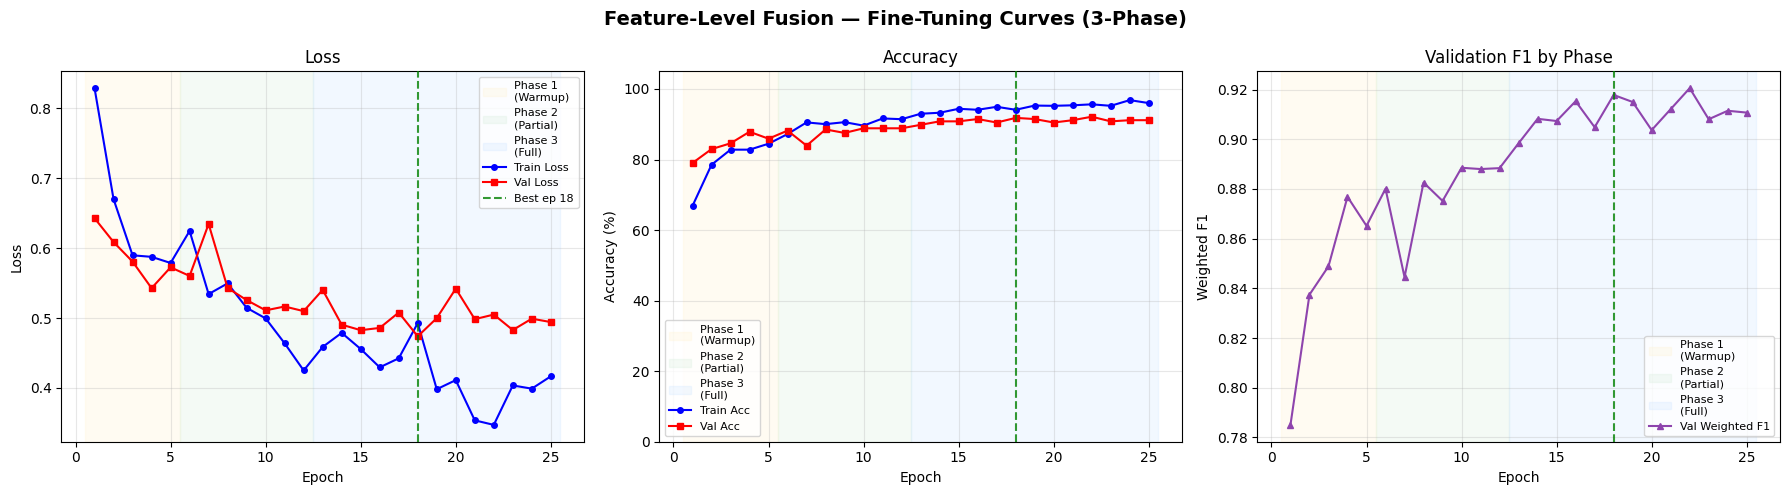


📊 Per-Phase Summary:
   Phase      Epochs       Best Val Acc    Best Val F1
   Warmup     ep 1-5       87.87          % 0.8768
   Partial    ep 6-12      88.85          % 0.8885
   Full       ep 13-25      92.13          % 0.9206

   Overall best val acc : 92.13%
   Overall best val F1  : 0.9206

✅ Step 8 complete.


In [8]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))
phases     = history["phase"]

# Phase boundary markers
ph2_start = next((i+1 for i,p in enumerate(phases) if p==2), None)
ph3_start = next((i+1 for i,p in enumerate(phases) if p==3), None)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Feature-Level Fusion — Fine-Tuning Curves (3-Phase)",
             fontsize=14, fontweight="bold")

def shade_phases(ax, phases, epochs):
    """Shade background by training phase."""
    colors_p = {1: "#fff3cd", 2: "#d4edda", 3: "#cce5ff"}
    labels_p = {1: "Phase 1\n(Warmup)", 2: "Phase 2\n(Partial)", 3: "Phase 3\n(Full)"}
    prev_p = None; start = 1
    for i, p in enumerate(phases):
        if p != prev_p:
            if prev_p is not None:
                ax.axvspan(start - 0.5, i + 0.5, alpha=0.25,
                           color=colors_p[prev_p], label=labels_p[prev_p])
            start = i + 1; prev_p = p
    ax.axvspan(start - 0.5, len(phases) + 0.5, alpha=0.25,
               color=colors_p[prev_p], label=labels_p[prev_p])

# Loss
ax = axes[0]
shade_phases(ax, phases, epochs_ran)
ax.plot(epochs_ran, history["train_loss"], "b-o", ms=4, label="Train Loss", zorder=5)
ax.plot(epochs_ran, history["val_loss"],   "r-s", ms=4, label="Val Loss",   zorder=5)
best_ep = history["val_loss"].index(min(history["val_loss"])) + 1
ax.axvline(best_ep, color="green", linestyle="--", alpha=0.8, label=f"Best ep {best_ep}", zorder=6)
ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Accuracy
ax2 = axes[1]
shade_phases(ax2, phases, epochs_ran)
ax2.plot(epochs_ran, [v*100 for v in history["train_acc"]], "b-o", ms=4, label="Train Acc", zorder=5)
ax2.plot(epochs_ran, [v*100 for v in history["val_acc"]],   "r-s", ms=4, label="Val Acc",   zorder=5)
ax2.axvline(best_ep, color="green", linestyle="--", alpha=0.8, zorder=6)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim([0, 105]); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# F1 with phase coloring
ax3 = axes[2]
shade_phases(ax3, phases, epochs_ran)
ax3.plot(epochs_ran, history["val_f1"], color="#8e44ad", marker="^",
         ms=4, label="Val Weighted F1", zorder=5)
ax3.axvline(best_ep, color="green", linestyle="--", alpha=0.8, zorder=6)
ax3.set_title("Validation F1 by Phase"); ax3.set_xlabel("Epoch")
ax3.set_ylabel("Weighted F1")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step8_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# Per-phase summary table
print("\n📊 Per-Phase Summary:")
print(f"   {'Phase':<10} {'Epochs':<12} {'Best Val Acc':<15} {'Best Val F1'}")
for ph, ph_name in [(1,"Warmup"),(2,"Partial"),(3,"Full")]:
    ep_idxs = [i for i,p in enumerate(phases) if p==ph]
    if ep_idxs:
        best_acc = max(history["val_acc"][i] for i in ep_idxs)
        best_f1  = max(history["val_f1"][i]  for i in ep_idxs)
        print(f"   {ph_name:<10} ep {ep_idxs[0]+1}-{ep_idxs[-1]+1:<7} "
              f"{best_acc*100:<15.2f}% {best_f1:.4f}")
print(f"\n   Overall best val acc : {max(history['val_acc'])*100:.2f}%")
print(f"   Overall best val F1  : {max(history['val_f1']):.4f}")
print("\n✅ Step 8 complete.")

---
## ✅ Step 9 — Final Test Evaluation & Metrics

**PDF Phase 6:** Load best fine-tuned checkpoint → run on test set **once only**.

In [9]:
# Load best fine-tuned checkpoint
ckpt = torch.load(FINETUNE_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"✅ Loaded best fine-tuned checkpoint:")
print(f"   Epoch    : {ckpt['epoch']}")
print(f"   Phase    : {ckpt['phase']} ({'Warmup' if ckpt['phase']==1 else 'Partial' if ckpt['phase']==2 else 'Full'})")
print(f"   Val loss : {ckpt['val_loss']:.4f}")
print(f"   Val acc  : {ckpt['val_acc']*100:.2f}%")
print(f"   Val F1   : {ckpt['val_f1']:.4f}")

print("\n🔬 Running inference on test set...")
test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, DEVICE)

acc_pct      = test_acc * 100
weighted_f1  = f1_score(test_true, test_preds, average="weighted", zero_division=0)
macro_f1     = f1_score(test_true, test_preds, average="macro",    zero_division=0)
per_class_f1 = f1_score(test_true, test_preds, average=None,       zero_division=0)

print("\n" + "=" * 62)
print("  FINAL TEST RESULTS — Feature-Level Fusion (Fine-Tuned)")
print("=" * 62)
print(f"  {'Accuracy':<28}{acc_pct:.2f}%")
print(f"  {'Weighted F1':<28}{weighted_f1:.4f}")
print(f"  {'Macro F1':<28}{macro_f1:.4f}")
print(f"  {'Test Loss':<28}{test_loss:.4f}")
print("-" * 62)
print("  Per-Class F1:")
for cls, f1 in zip(CLASS_NAMES, per_class_f1):
    print(f"    {cls:<22} {f1:.4f}  {'█' * int(f1 * 30)}")
print("=" * 62)

print("\n📋 Full Classification Report:")
print(classification_report(test_true, test_preds,
                             target_names=CLASS_NAMES, digits=4))

pd.DataFrame({
    "Metric": ["Accuracy","Weighted F1","Macro F1"] + [f"F1_{c}" for c in CLASS_NAMES],
    "Value":  [acc_pct/100, weighted_f1, macro_f1]  + list(per_class_f1)
}).to_csv(f"/kaggle/working/{PREFIX}_step9_test_results.csv", index=False)
print("\n✅ Step 9 complete — results saved.")

✅ Loaded best fine-tuned checkpoint:
   Epoch    : 18
   Phase    : 3 (Full)
   Val loss : 0.4738
   Val acc  : 91.80%
   Val F1   : 0.9178

🔬 Running inference on test set...

  FINAL TEST RESULTS — Feature-Level Fusion (Fine-Tuned)
  Accuracy                    93.16%
  Weighted F1                 0.9319
  Macro F1                    0.9215
  Test Loss                   0.4226
--------------------------------------------------------------
  Per-Class F1:
    Healthy_Leaf           0.9467  ████████████████████████████
    Leaf_Rot               0.8941  ██████████████████████████
    Leaf_Spot              0.9238  ███████████████████████████

📋 Full Classification Report:
              precision    recall  f1-score   support

Healthy_Leaf     0.9618    0.9321    0.9467       162
    Leaf_Rot     0.8636    0.9268    0.8941        41
   Leaf_Spot     0.9151    0.9327    0.9238       104

    accuracy                         0.9316       307
   macro avg     0.9135    0.9305    0.9215    

---
## ✅ Step 10 — Confusion Matrix, Per-Class Report & Fine-Tuning Summary

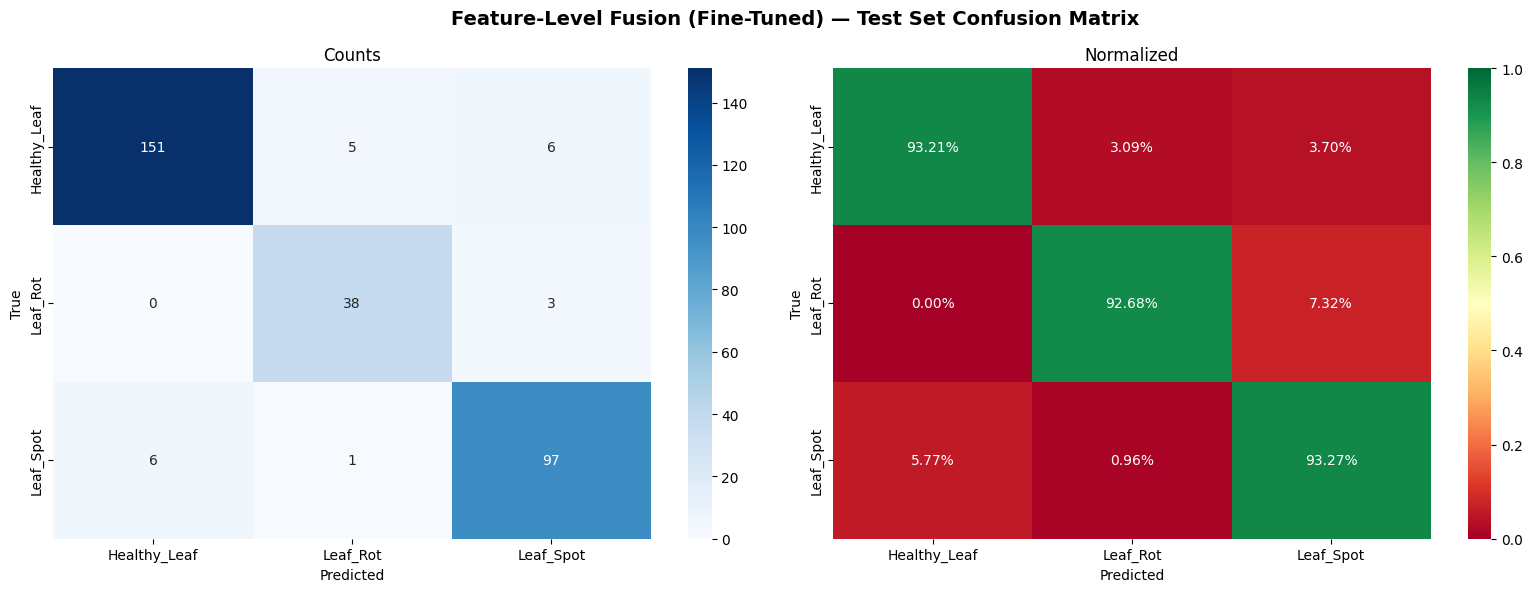

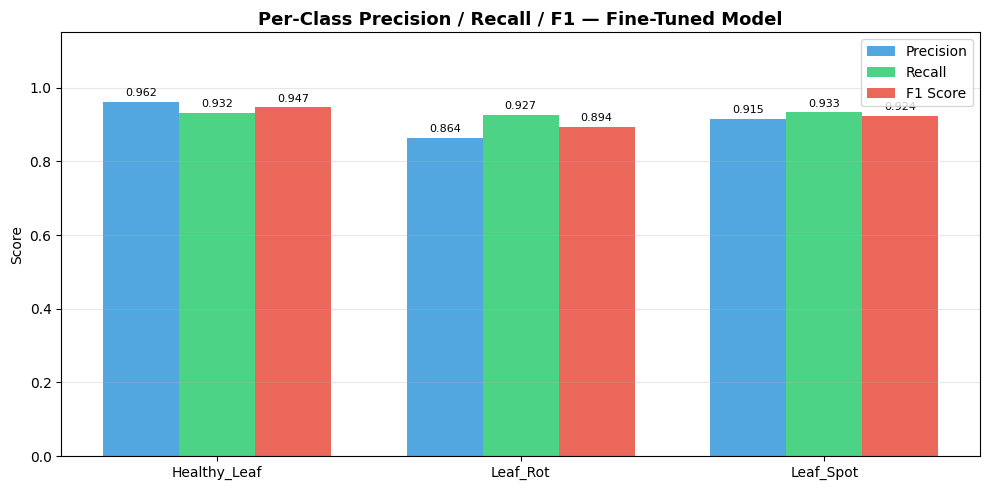

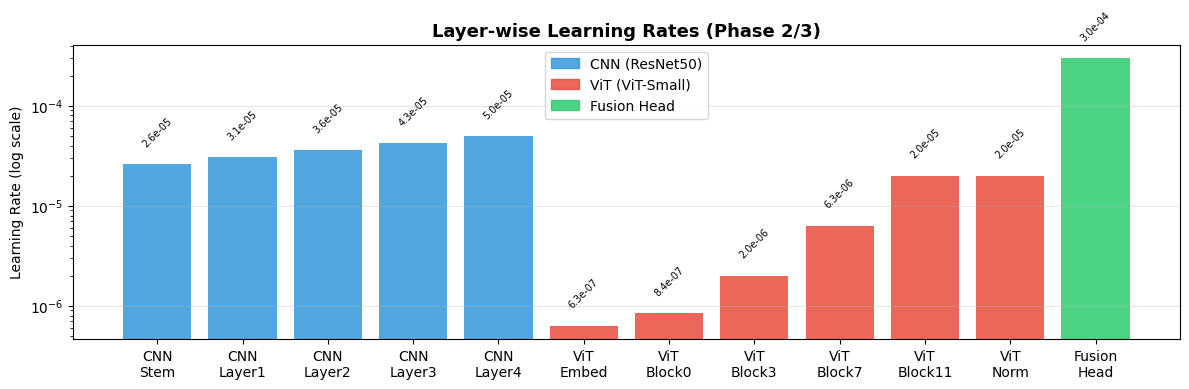


════════════════════════════════════════════════════════════════════
  🌿 FEATURE-LEVEL FUSION — FINE-TUNING FINAL SUMMARY
════════════════════════════════════════════════════════════════════
  Model          : ResNet50 (CNN) + ViT-Small (Transformer)
  Fusion vector  : 2048 + 384 = 2432 dims → MLP(512) → 3
  Fine-tune      : 3-Phase (Warmup → Partial → Full)
  Mixup alpha    : 0.2
  Layer-wise LR  : CNN decay=0.85 | ViT decay=0.75
  Test Accuracy  : 93.16%
  Weighted F1    : 0.9319
  Macro F1       : 0.9215
────────────────────────────────────────────────────────────────────
    Healthy_Leaf        F1=0.9467  Prec=0.9618  Rec=0.9321
    Leaf_Rot            F1=0.8941  Prec=0.8636  Rec=0.9268
    Leaf_Spot           F1=0.9238  Prec=0.9151  Rec=0.9327
────────────────────────────────────────────────────────────────────
  Saved files:
    ✓ /kaggle/working/feat_ft_step3_distribution.png
    ✓ /kaggle/working/feat_ft_step4_augmentation.png
    ✓ /kaggle/working/feat_ft_step8_training_curve

In [10]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm      = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Feature-Level Fusion (Fine-Tuned) — Test Set Confusion Matrix",
             fontsize=14, fontweight="bold")
sns.heatmap(cm,      annot=True, fmt="d",   cmap="Blues",  ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title("Counts")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="RdYlGn", ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
axes[1].set_title("Normalized")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Per-class Precision / Recall / F1 ────────────────────────────────────
per_prec   = precision_score(test_true, test_preds, average=None, zero_division=0)
per_recall = recall_score(test_true,    test_preds, average=None, zero_division=0)

fig2, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CLASS_NAMES)); w = 0.25
b1 = ax.bar(x - w, per_prec,     w, label="Precision", color="#3498db", alpha=0.85)
b2 = ax.bar(x,     per_recall,   w, label="Recall",    color="#2ecc71", alpha=0.85)
b3 = ax.bar(x + w, per_class_f1, w, label="F1 Score",  color="#e74c3c", alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_title("Per-Class Precision / Recall / F1 — Fine-Tuned Model",
             fontsize=13, fontweight="bold")
ax.set_ylim([0, 1.15]); ax.set_ylabel("Score")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_per_class_metrics.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Layer-wise LR schedule visualization ─────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(12, 4))
layer_names = ["CNN\nStem", "CNN\nLayer1", "CNN\nLayer2", "CNN\nLayer3", "CNN\nLayer4",
               "ViT\nEmbed", "ViT\nBlock0", "ViT\nBlock3", "ViT\nBlock7",
               "ViT\nBlock11","ViT\nNorm",  "Fusion\nHead"]
lrs_p2 = [
    CNN_BASE_LR * CNN_LR_DECAY**4,   # stem
    CNN_BASE_LR * CNN_LR_DECAY**3,   # layer1
    CNN_BASE_LR * CNN_LR_DECAY**2,   # layer2
    CNN_BASE_LR * CNN_LR_DECAY**1,   # layer3
    CNN_BASE_LR * CNN_LR_DECAY**0,   # layer4
    VIT_BASE_LR * VIT_LR_DECAY**12,  # embed
    VIT_BASE_LR * VIT_LR_DECAY**11,  # block0
    VIT_BASE_LR * VIT_LR_DECAY**8,   # block3
    VIT_BASE_LR * VIT_LR_DECAY**4,   # block7
    VIT_BASE_LR * VIT_LR_DECAY**0,   # block11
    VIT_BASE_LR,                      # norm
    HEAD_LR_FINE,                     # head
]
bar_colors = (["#3498db"]*5 + ["#e74c3c"]*6 + ["#2ecc71"]*1)
bars = ax3.bar(layer_names, lrs_p2, color=bar_colors, alpha=0.85)
ax3.set_yscale("log")
ax3.set_title("Layer-wise Learning Rates (Phase 2/3)", fontsize=13, fontweight="bold")
ax3.set_ylabel("Learning Rate (log scale)")
for bar, lr in zip(bars, lrs_p2):
    ax3.text(bar.get_x() + bar.get_width()/2, lr * 1.5,
             f"{lr:.1e}", ha="center", fontsize=7, rotation=45)
patch_cnn  = mpatches.Patch(color="#3498db", alpha=0.85, label="CNN (ResNet50)")
patch_vit  = mpatches.Patch(color="#e74c3c", alpha=0.85, label="ViT (ViT-Small)")
patch_head = mpatches.Patch(color="#2ecc71", alpha=0.85, label="Fusion Head")
ax3.legend(handles=[patch_cnn, patch_vit, patch_head])
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_layerwise_lr.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Final summary ─────────────────────────────────────────────────────────
print("\n" + "═" * 68)
print("  🌿 FEATURE-LEVEL FUSION — FINE-TUNING FINAL SUMMARY")
print("═" * 68)
print(f"  Model          : ResNet50 (CNN) + ViT-Small (Transformer)")
print(f"  Fusion vector  : {CNN_FEAT_DIM} + {VIT_FEAT_DIM} = {FUSED_DIM} dims → MLP({FUSION_HIDDEN}) → {NUM_CLASSES}")
print(f"  Fine-tune      : 3-Phase (Warmup → Partial → Full)")
print(f"  Mixup alpha    : {MIXUP_ALPHA}")
print(f"  Layer-wise LR  : CNN decay={CNN_LR_DECAY} | ViT decay={VIT_LR_DECAY}")
print(f"  Test Accuracy  : {acc_pct:.2f}%")
print(f"  Weighted F1    : {weighted_f1:.4f}")
print(f"  Macro F1       : {macro_f1:.4f}")
print("─" * 68)
for cls, f1, p, r in zip(CLASS_NAMES, per_class_f1, per_prec, per_recall):
    print(f"    {cls:<18}  F1={f1:.4f}  Prec={p:.4f}  Rec={r:.4f}")
print("─" * 68)
print("  Saved files:")
for f in [
    f"{PREFIX}_step3_distribution.png",
    f"{PREFIX}_step4_augmentation.png",
    f"{PREFIX}_step8_training_curves.png",
    f"{PREFIX}_step9_test_results.csv",
    f"{PREFIX}_step10_confusion_matrix.png",
    f"{PREFIX}_step10_per_class_metrics.png",
    f"{PREFIX}_step10_layerwise_lr.png",
    "best_feat_fusion_finetuned.pth",
]:
    print(f"    ✓ /kaggle/working/{f}")
print("═" * 68)
print("  ✅ Step 10 complete — Fine-tuning pipeline finished!")
print("═" * 68)